Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Read data

In [2]:
df = pd.read_csv("../data/framingham.csv")

Shape of the dataset 

In [3]:
print(df.shape)

(4240, 16)


Description of the dataset

In [4]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


Missing values analysis

In [6]:
missing_values = df.isnull().sum().sort_values(ascending=False)

print(missing_values)

#Use AI to be sure of the end of the function (sort_values)

glucose            388
education          105
BPMeds              53
totChol             50
cigsPerDay          29
BMI                 19
heartRate            1
male                 0
prevalentHyp         0
prevalentStroke      0
age                  0
currentSmoker        0
diaBP                0
sysBP                0
diabetes             0
TenYearCHD           0
dtype: int64


Several variables contain missing values, especially glucose, education, BPMeds, and totChol. Since these variables may influence cardiovascular risk, handling missing data properly is necessary before starting the exploratory analysis.

Check if duplicates

In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


Numerical and Categorical review

In [8]:
numeric_cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]

categorical_cols = [col for col in df.columns if df[col].dtype == 'object']

print("Numerical variables:")
print(numeric_cols)

print("\nCategorical variables:")
print(categorical_cols)

Numerical variables:
['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']

Categorical variables:
[]


Modify type of variables

In [9]:
df['male'] = df['male'].astype('object')
df['education'] = df['education'].astype('object')
df['currentSmoker'] = df['currentSmoker'].astype('object')
df['BPMeds'] = df['BPMeds'].astype('object')
df['prevalentStroke'] = df['prevalentStroke'].astype('object')
df['prevalentHyp'] = df['prevalentHyp'].astype('object')
df['diabetes'] = df['diabetes'].astype('object')
df['TenYearCHD'] = df['TenYearCHD'].astype('object')

numeric_cols.remove('male')
numeric_cols.remove('education')
numeric_cols.remove('currentSmoker')
numeric_cols.remove('BPMeds')
numeric_cols.remove('prevalentStroke')
numeric_cols.remove('prevalentHyp')
numeric_cols.remove('diabetes')
numeric_cols.remove('TenYearCHD')

In [21]:
categorical_cols = [col for col in df.columns if df[col].dtype == 'object']

print("Categorical variables:")
print(categorical_cols)
#AI to know how to link object with categorical cols

Categorical variables:
['male', 'education', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'TenYearCHD']


In [19]:
print("Numerical variables:")
print(numeric_cols)

print("\nCategorical variables:")
print(categorical_cols)

Numerical variables:
['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

Categorical variables:
['male', 'education', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'TenYearCHD']


In [20]:
categorical_cols.append('male')
categorical_cols.append('education')
categorical_cols.append('currentSmoker')
categorical_cols.append('BPMeds')
categorical_cols.append('prevalentStroke')
categorical_cols.append('prevalentHyp')
categorical_cols.append('diabetes')
categorical_cols.append('TenYearCHD')
df.describe(include='object')

,male,education,currentSmoker,BPMeds,prevalentStroke,prevalentHyp,diabetes,TenYearCHD
count,4240,4135.0,4240,4187.0,4240,4240,4240,4240
unique,2,4.0,2,2.0,2,2,2,2
top,0,1.0,0,0.0,0,0,0,0
freq,2420,1720.0,2145,4063.0,4215,2923,4131,3596


Univariate Analysis

Numerical values

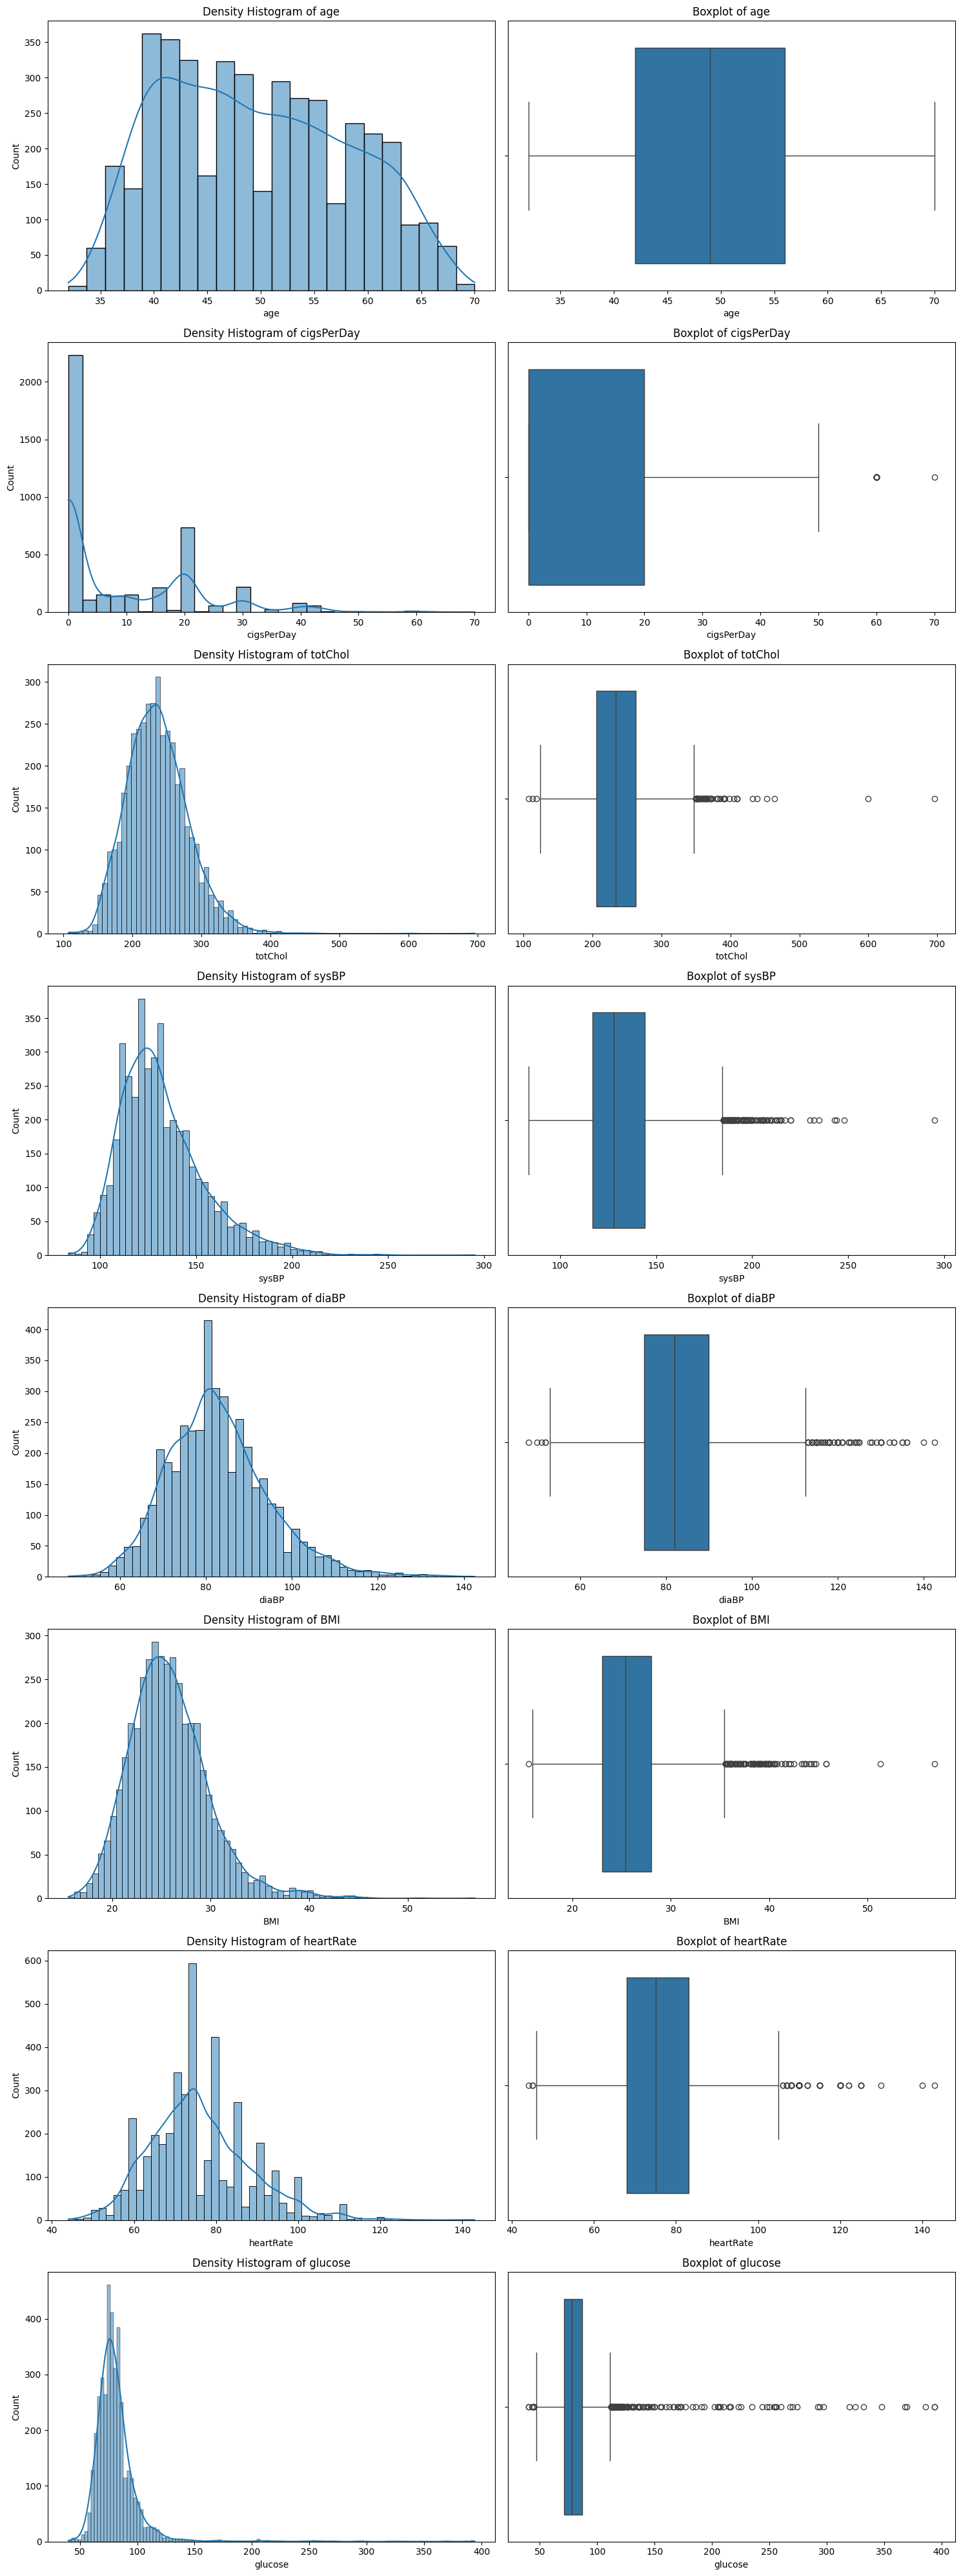

In [23]:
fig, axes = plt.subplots(
    nrows=len(numeric_cols),
    ncols=2,
    figsize=(15, 5 * len(numeric_cols))
)

for i, column in enumerate(numeric_cols):
    # Density histogram
    sns.histplot(df[column], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Density Histogram of {column}')
    axes[i, 0].set_xlabel(column)

    # Boxplot
    sns.boxplot(x=df[column], ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot of {column}')
    axes[i, 1].set_xlabel(column)

plt.tight_layout()
plt.show()

Variables with low cardinality

In [24]:
numeric_cols_low_cardinality = [
    col for col in numeric_cols if df[col].nunique() < 50
]

df[numeric_cols_low_cardinality].describe(
    percentiles=[.25, .5, .75, .90, .95, .99]
).T.sort_values(
    by='50%', ascending=False
).style.background_gradient(cmap='coolwarm')

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
age,4240.000000,49.580189,8.572942,32.000000,42.000000,49.000000,56.000000,62.000000,64.000000,67.000000,70.000000
cigsPerDay,4211.000000,9.005937,11.922462,0.000000,0.000000,0.000000,20.000000,25.000000,30.000000,43.000000,70.000000


Aplicate Logarithm to low cardinality variable

In [25]:
df_low_c_logged = df[numeric_cols_low_cardinality].copy()
for col in df_low_c_logged.columns:
    if df_low_c_logged[col].min() > 0:
        df_low_c_logged[col] = np.log(df_low_c_logged[col])
    else:
        df_low_c_logged[col] = np.log(df_low_c_logged[col] + 1)

Visualization of histogram with low cardinality

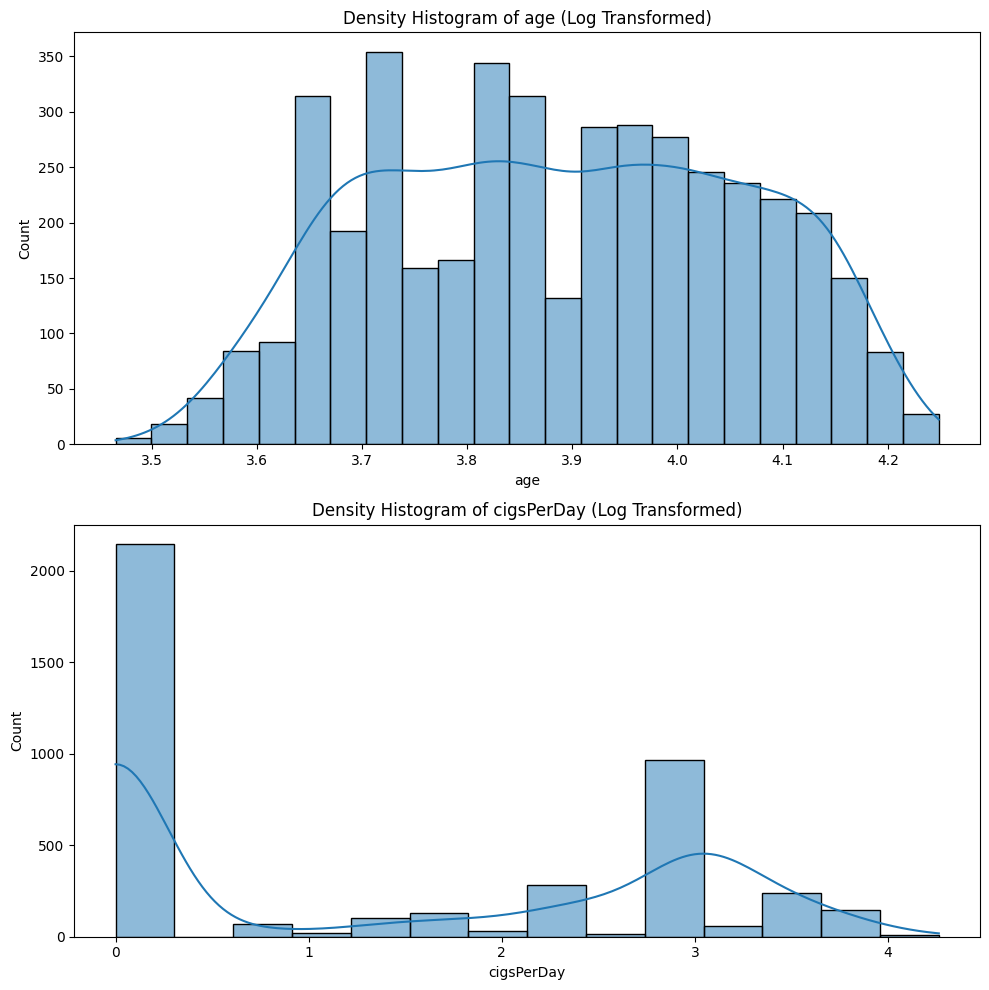

In [26]:
fig, axs = plt.subplots(
    nrows=len(df_low_c_logged.columns),
    ncols=1,
    figsize=(10, 5 * len(df_low_c_logged.columns))
)

for i, column in enumerate(df_low_c_logged.columns):
    # Density histogram after log transformation
    sns.histplot(df_low_c_logged[column], kde=True, ax=axs[i])
    axs[i].set_title(f'Density Histogram of {column} (Log Transformed)')
    axs[i].set_xlabel(column)

plt.tight_layout()
plt.show()

Categorical values

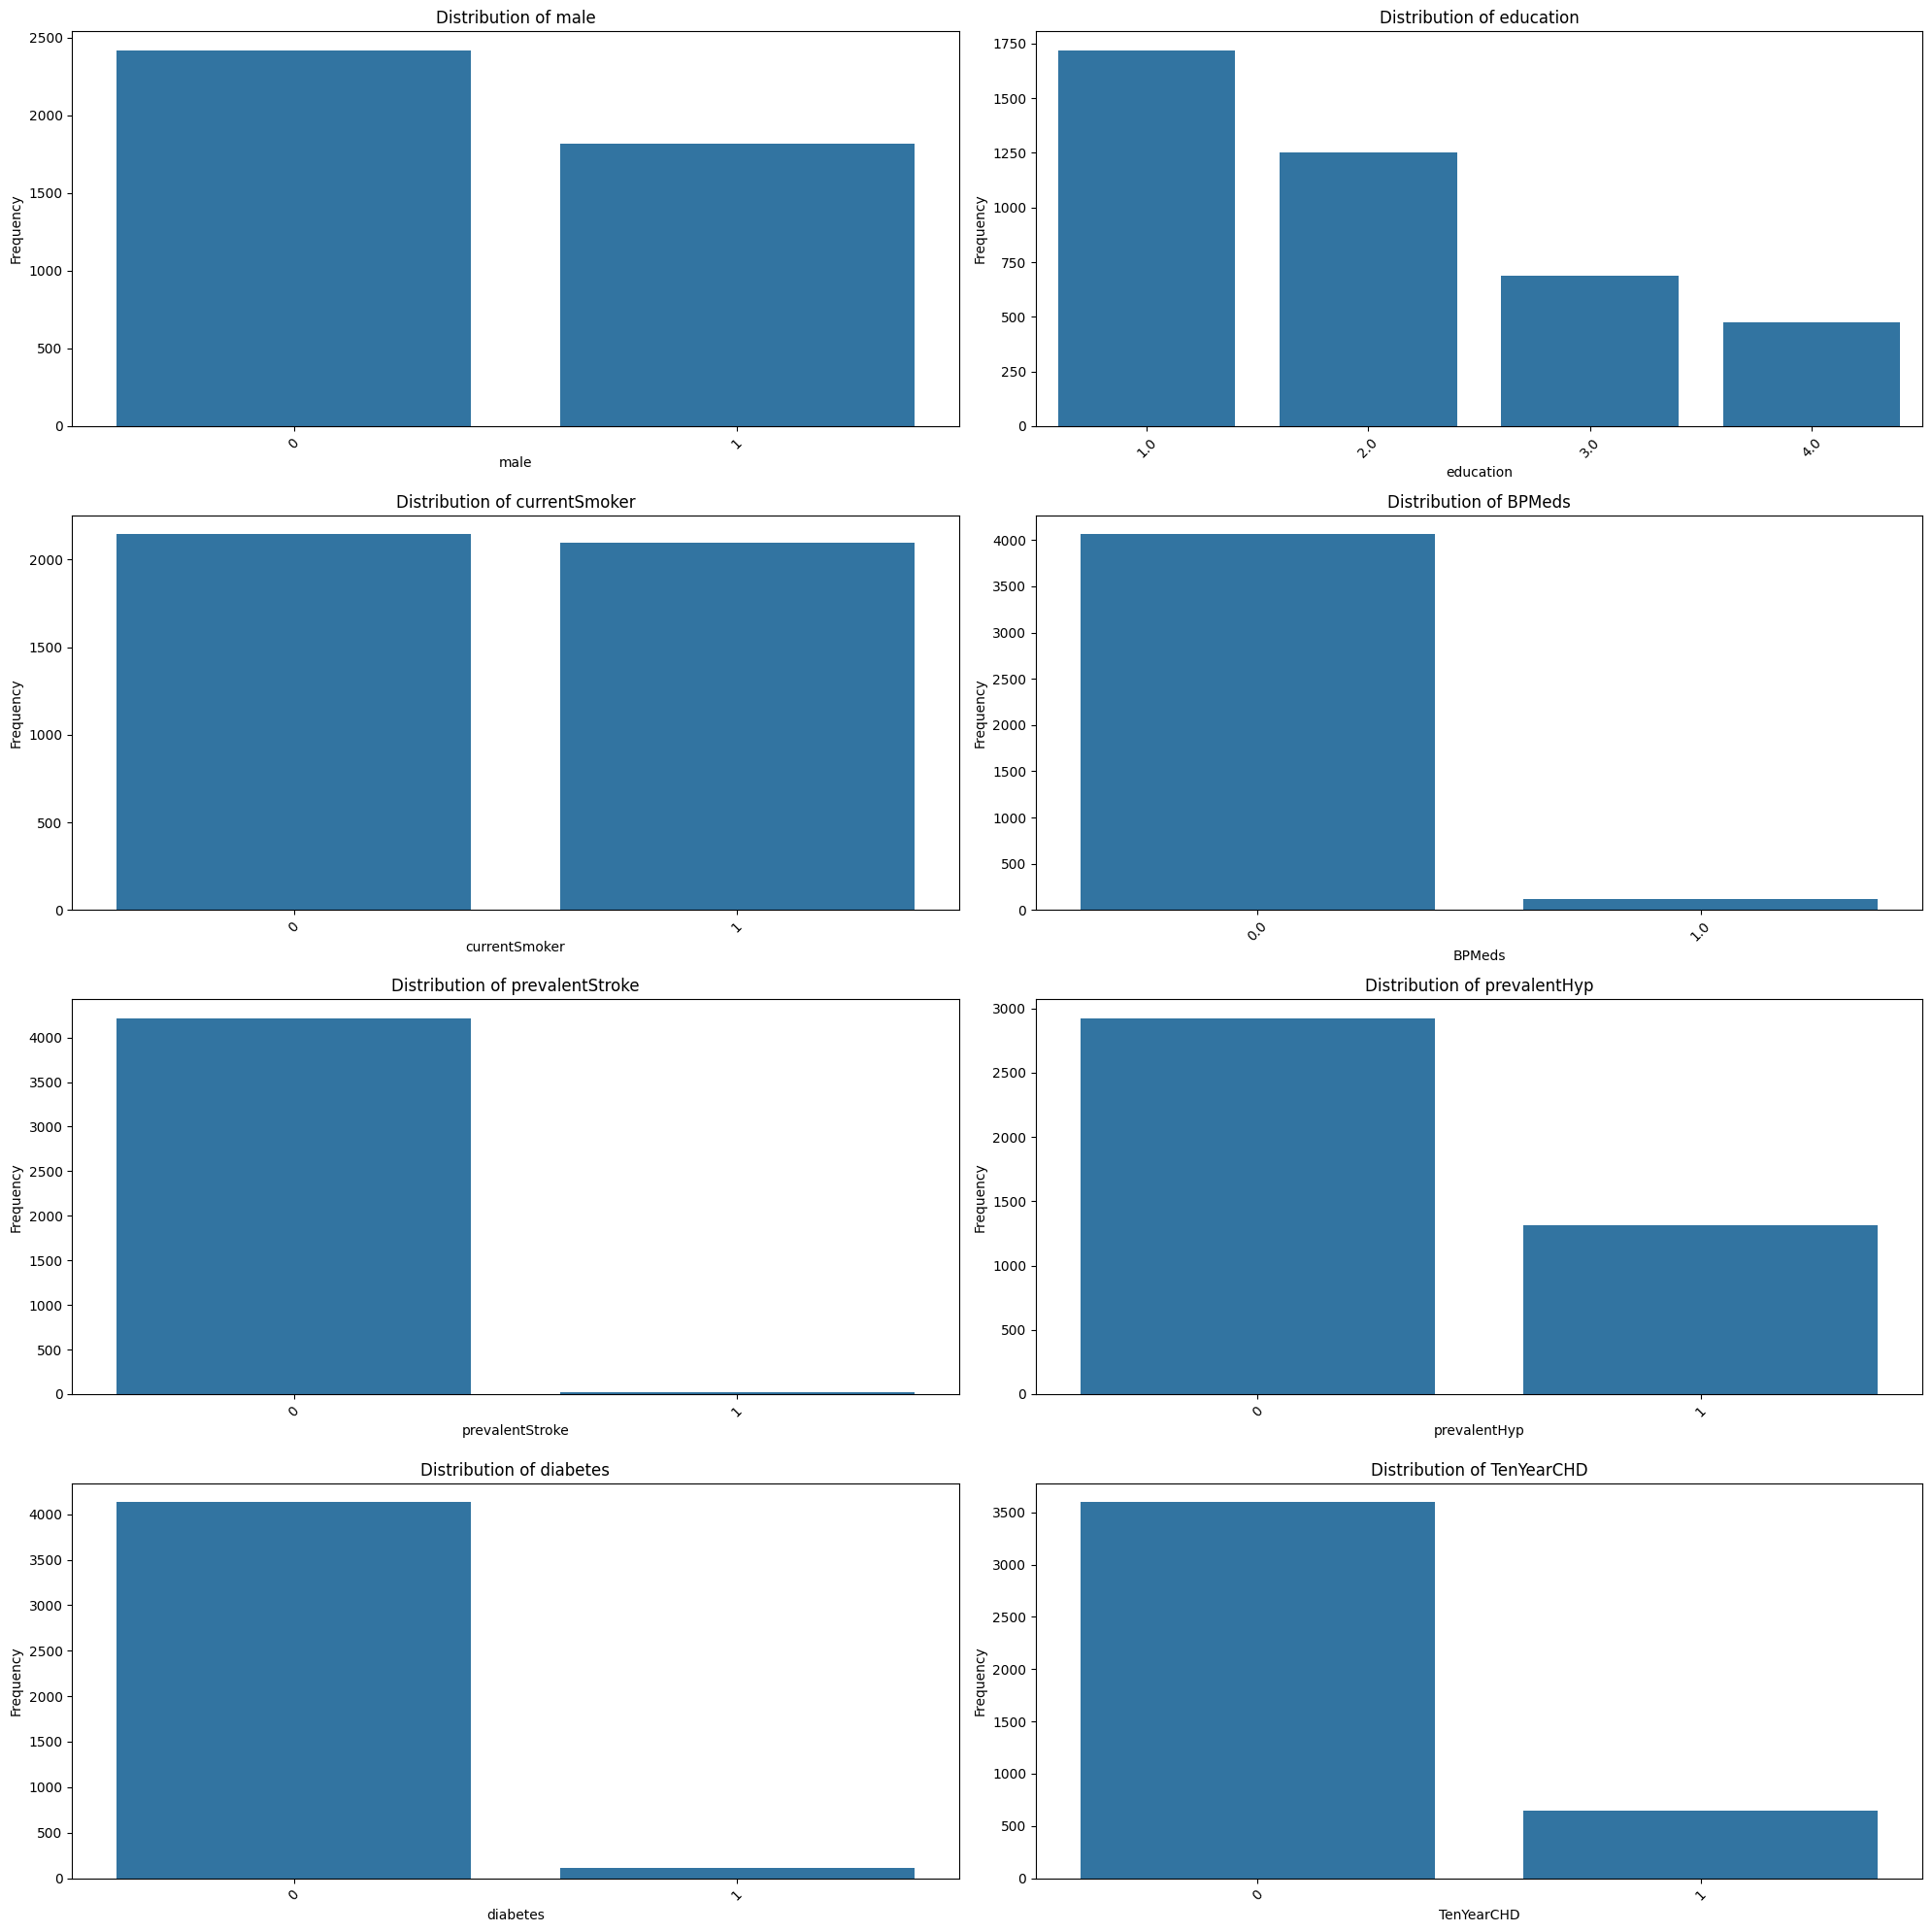

In [27]:
fig, axs = plt.subplots(
    nrows=len(categorical_cols) // 2 + len(categorical_cols) % 2,
    ncols=2,
    figsize=(20, 5 * (len(categorical_cols) // 2 + len(categorical_cols) % 2))
)

# Flatten axes array for easier iteration
axs = axs.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index,
        ax=axs[i]
    )
    
    axs[i].set_title(f'Distribution of {col}')
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Frequency')
    axs[i].tick_params(axis='x', rotation=45)

# Remove empty subplot if odd number of variables
if len(categorical_cols) % 2 != 0:
    fig.delaxes(axs[-1])

plt.tight_layout()
plt.show()

Bivariate Analysis VS Target

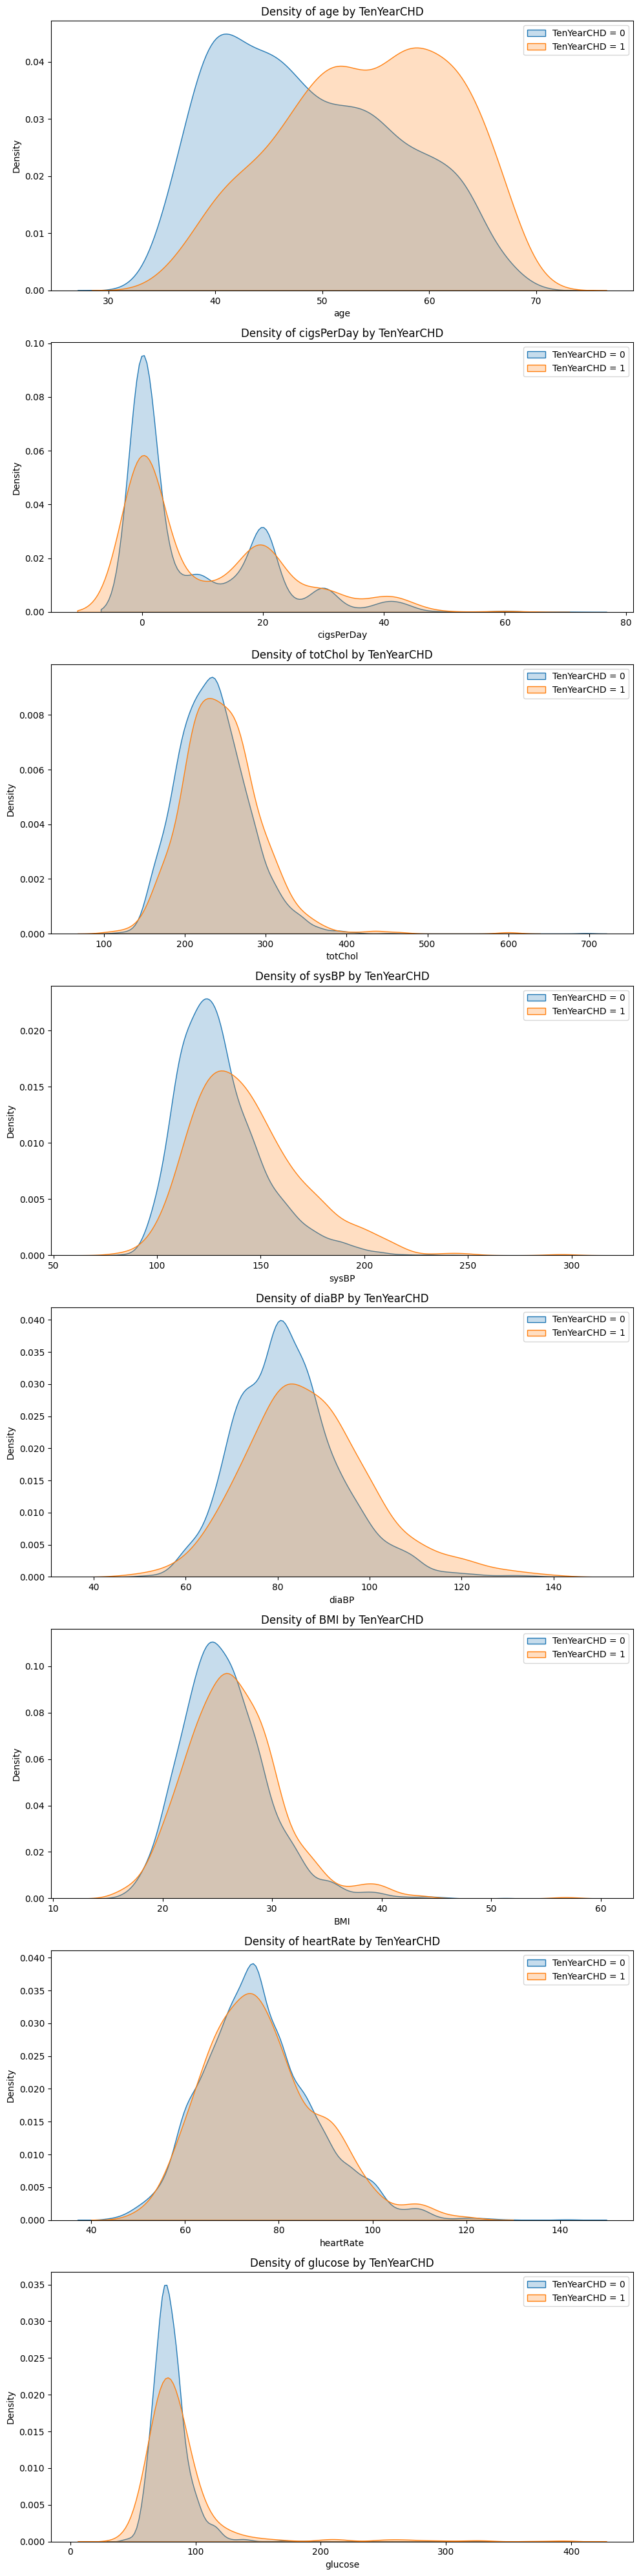

In [28]:
target = 'TenYearCHD'

fig, axs = plt.subplots(
    nrows=len(numeric_cols),
    ncols=1,
    figsize=(10, 5 * len(numeric_cols))
)

for i, col in enumerate(numeric_cols):
    sns.kdeplot(
        data=df[df[target] == df[target].unique()[0]],
        x=col,
        ax=axs[i],
        label=f'{target} = {df[target].unique()[0]}',
        fill=True
    )
    
    sns.kdeplot(
        data=df[df[target] == df[target].unique()[1]],
        x=col,
        ax=axs[i],
        label=f'{target} = {df[target].unique()[1]}',
        fill=True
    )
    
    axs[i].set_title(f'Density of {col} by {target}')
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Density')
    axs[i].legend()

plt.tight_layout()
plt.show()

Winsorization of low-cardinality numerical variables

In [29]:

def winsorize_upper(df, columns, upper_percentile=0.99):
    """
    Winsorize the upper tail of selected columns at a given percentile.
    """
    for col in columns:
        upper_limit = df[col].quantile(upper_percentile)
        df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])
    return df


df_winsorized = winsorize_upper(df.copy(), numeric_cols_low_cardinality)

Bivariate Visualization

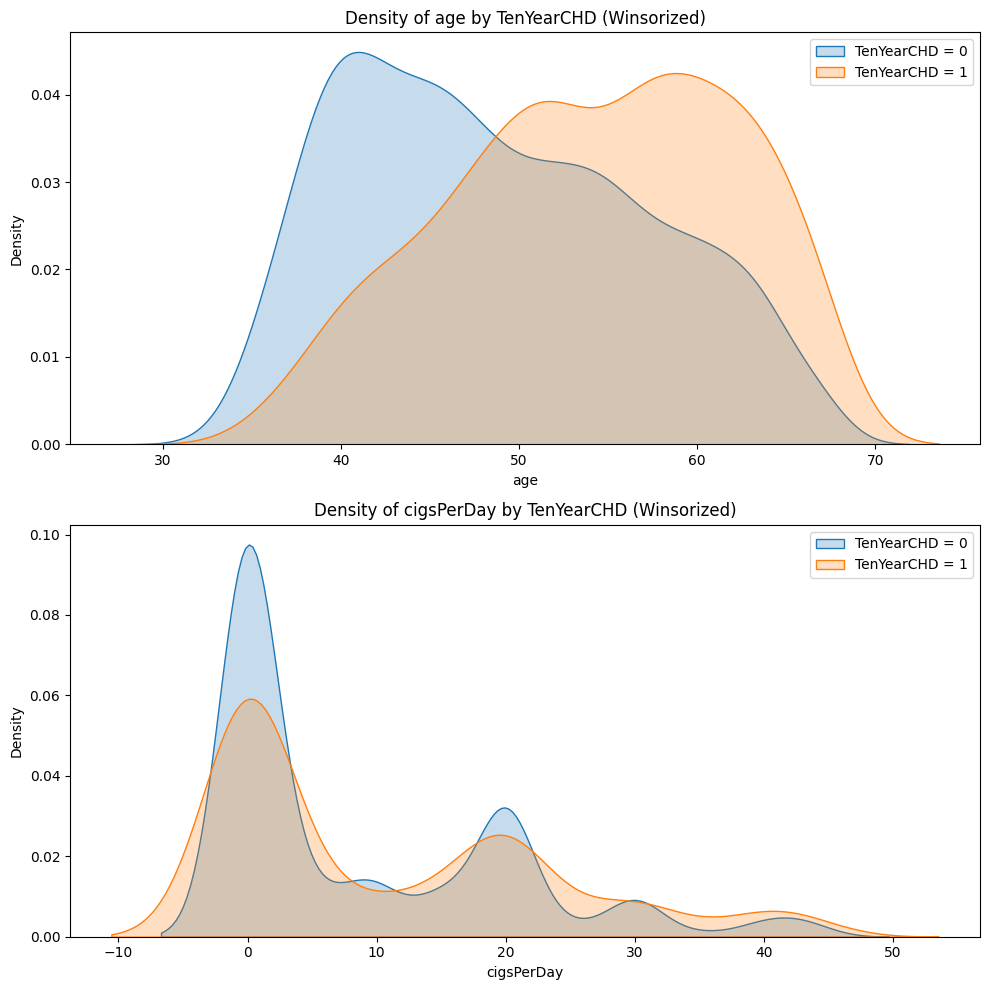

In [30]:
target = 'TenYearCHD'

fig, axs = plt.subplots(
    nrows=len(numeric_cols_low_cardinality),
    ncols=1,
    figsize=(10, 5 * len(numeric_cols_low_cardinality))
)

for i, col in enumerate(numeric_cols_low_cardinality):
    sns.kdeplot(
        data=df_winsorized[df_winsorized[target] == df_winsorized[target].unique()[0]],
        x=col,
        ax=axs[i],
        label=f'{target} = {df_winsorized[target].unique()[0]}',
        fill=True
    )
    
    sns.kdeplot(
        data=df_winsorized[df_winsorized[target] == df_winsorized[target].unique()[1]],
        x=col,
        ax=axs[i],
        label=f'{target} = {df_winsorized[target].unique()[1]}',
        fill=True
    )
    
    axs[i].set_title(f'Density of {col} by {target} (Winsorized)')
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Density')
    axs[i].legend()

plt.tight_layout()
plt.show()

Numerical variables detailed percentile

In [31]:
df[numeric_cols].describe(
    percentiles=[.25, .5, .75, .90, .95, .99]
).T.sort_values(
    by='50%',
    ascending=False
).style.background_gradient(cmap='coolwarm')

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
totChol,4190.000000,236.699523,44.591284,107.000000,206.000000,234.000000,263.000000,292.000000,312.000000,354.110000,696.000000
sysBP,4240.000000,132.354599,22.033300,83.500000,117.000000,128.000000,144.000000,162.000000,175.000000,200.000000,295.000000
diaBP,4240.000000,82.897759,11.910394,48.000000,75.000000,82.000000,90.000000,98.000000,104.525000,118.000000,142.500000
glucose,3852.000000,81.963655,23.954335,40.000000,71.000000,78.000000,87.000000,98.000000,108.450000,174.960000,394.000000
heartRate,4239.000000,75.878981,12.025348,44.000000,68.000000,75.000000,83.000000,92.000000,98.000000,110.000000,143.000000
age,4240.000000,49.580189,8.572942,32.000000,42.000000,49.000000,56.000000,62.000000,64.000000,67.000000,70.000000
BMI,4221.000000,25.800801,4.079840,15.540000,23.070000,25.400000,28.040000,30.770000,32.780000,38.956000,56.800000
cigsPerDay,4211.000000,9.005937,11.922462,0.000000,0.000000,0.000000,20.000000,25.000000,30.000000,43.000000,70.000000


For variables where most values are concentrated in one value, we analyze the distribution excluding the most common value

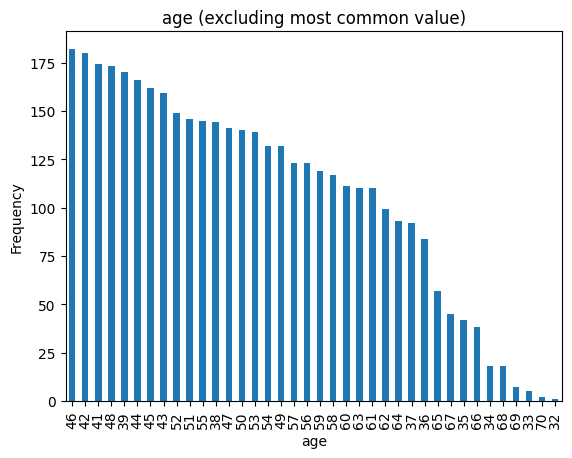

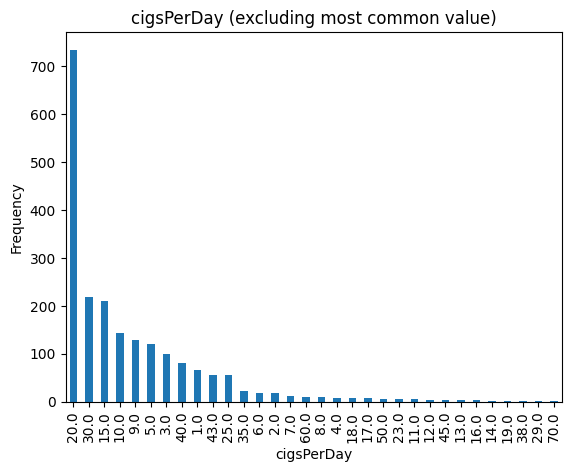

In [32]:
for col in df[numeric_cols_low_cardinality].columns:
    most_common_value = df[col].value_counts().idxmax()
    
    filtered_data = df[col][df[col] != most_common_value]
    
    plt.figure()
    filtered_data.value_counts().plot(kind='bar')
    plt.title(f'{col} (excluding most common value)')
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

Distribution of categorical variables according to the target variable

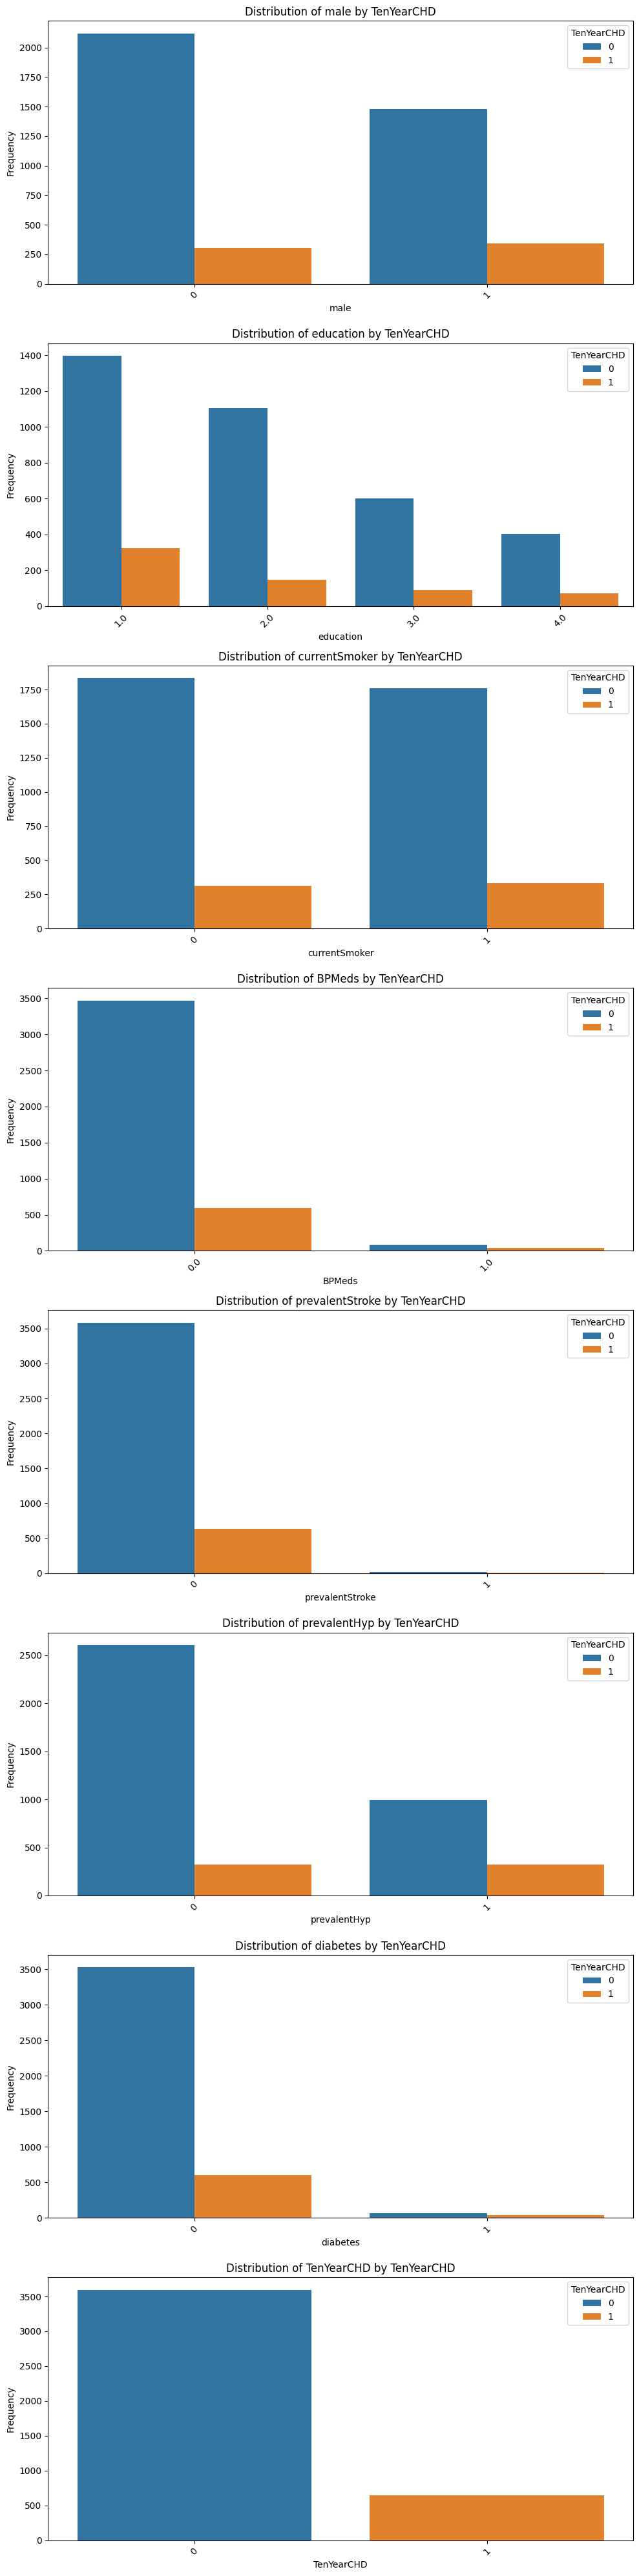

In [33]:
fig, axs = plt.subplots(
    nrows=len(categorical_cols),
    ncols=1,
    figsize=(10, 5 * len(categorical_cols))
)

for i, col in enumerate(categorical_cols):
    sns.countplot(
        data=df,
        x=col,
        hue=target,
        ax=axs[i],
        order=df[col].value_counts().index
    )
    
    axs[i].set_title(f'Distribution of {col} by {target}')
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Frequency')
    axs[i].tick_params(axis='x', rotation=45)
    axs[i].legend(title=target)

plt.tight_layout()
plt.show()

More specific bivariate analysis of the target variable

In [34]:
chd_perc = df['TenYearCHD'].value_counts(normalize=True)

chd_perc

TenYearCHD
0    0.848113
1    0.151887
Name: proportion, dtype: float64

Does CHD occur more in men or women?

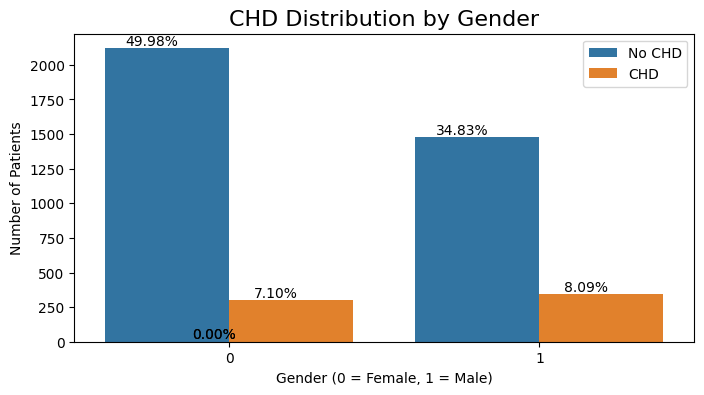

In [35]:
plt.figure(figsize=(8, 4))

# Create the countplot
ax1 = sns.countplot(
    x='male',
    hue='TenYearCHD',
    data=df
)

ax1.legend(bbox_to_anchor=(1, 1))

total = len(df)

for p in ax1.patches:
    percentage = '{:.2f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height()
    ax1.annotate(
        percentage,
        (x, y),
        ha='center',
        va='bottom'
    )

plt.title('CHD Distribution by Gender', size=16)
plt.xlabel('Gender (0 = Female, 1 = Male)')
plt.ylabel('Number of Patients')
plt.legend(['No CHD', 'CHD'])

plt.show()

Does CHD risk increase with age groups?

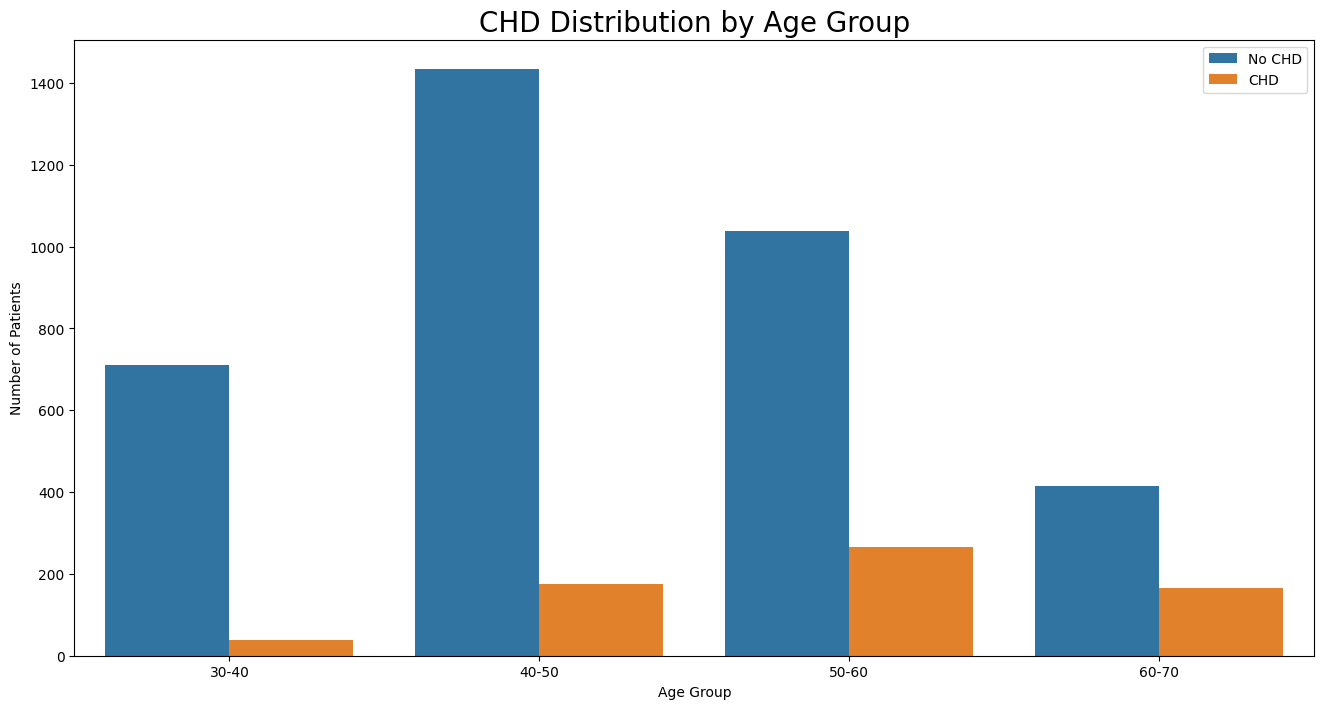

In [36]:
# Create age groups
df['age_group'] = pd.cut(
    df['age'],
    bins=[30, 40, 50, 60, 70],
    labels=['30-40', '40-50', '50-60', '60-70']
)

plt.figure(figsize=(16, 8))

ax1 = sns.countplot(
    x='age_group',
    hue='TenYearCHD',
    data=df
)

legend_labels, _ = ax1.get_legend_handles_labels()

plt.title('CHD Distribution by Age Group', size=20)
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.legend(['No CHD', 'CHD'])

plt.show()

Is there a relationship between systolic blood pressure and CHD?

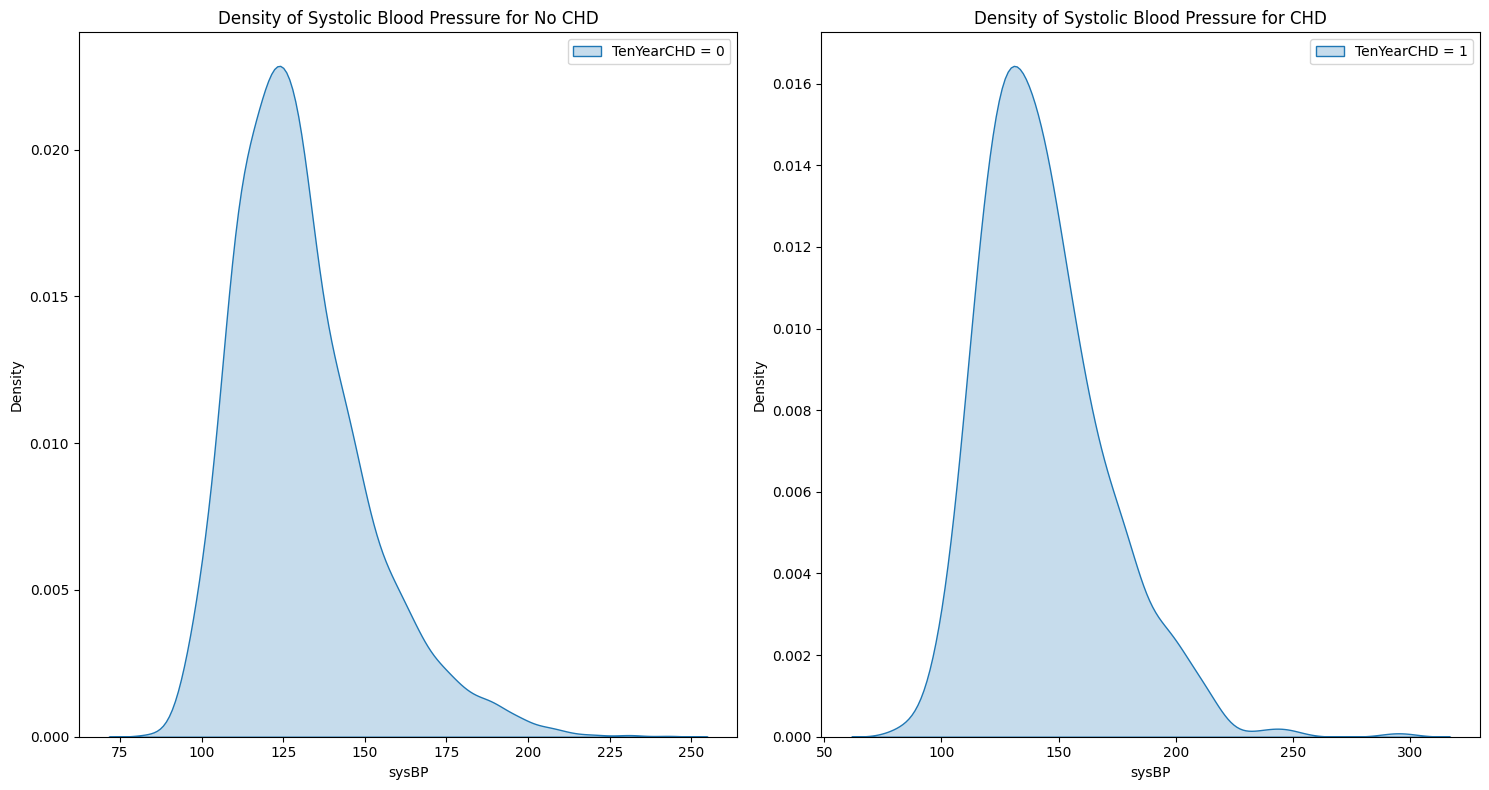

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# First graph: No CHD
sns.kdeplot(
    data=df[df[target] == df[target].unique()[0]],
    x='sysBP',
    label=f'{target} = {df[target].unique()[0]}',
    fill=True,
    ax=axes[0]
)

axes[0].set_title('Density of Systolic Blood Pressure for No CHD')
axes[0].set_xlabel('sysBP')
axes[0].set_ylabel('Density')
axes[0].legend()

# Second graph: CHD
sns.kdeplot(
    data=df[df[target] == df[target].unique()[1]],
    x='sysBP',
    label=f'{target} = {df[target].unique()[1]}',
    fill=True,
    ax=axes[1]
)

axes[1].set_title('Density of Systolic Blood Pressure for CHD')
axes[1].set_xlabel('sysBP')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

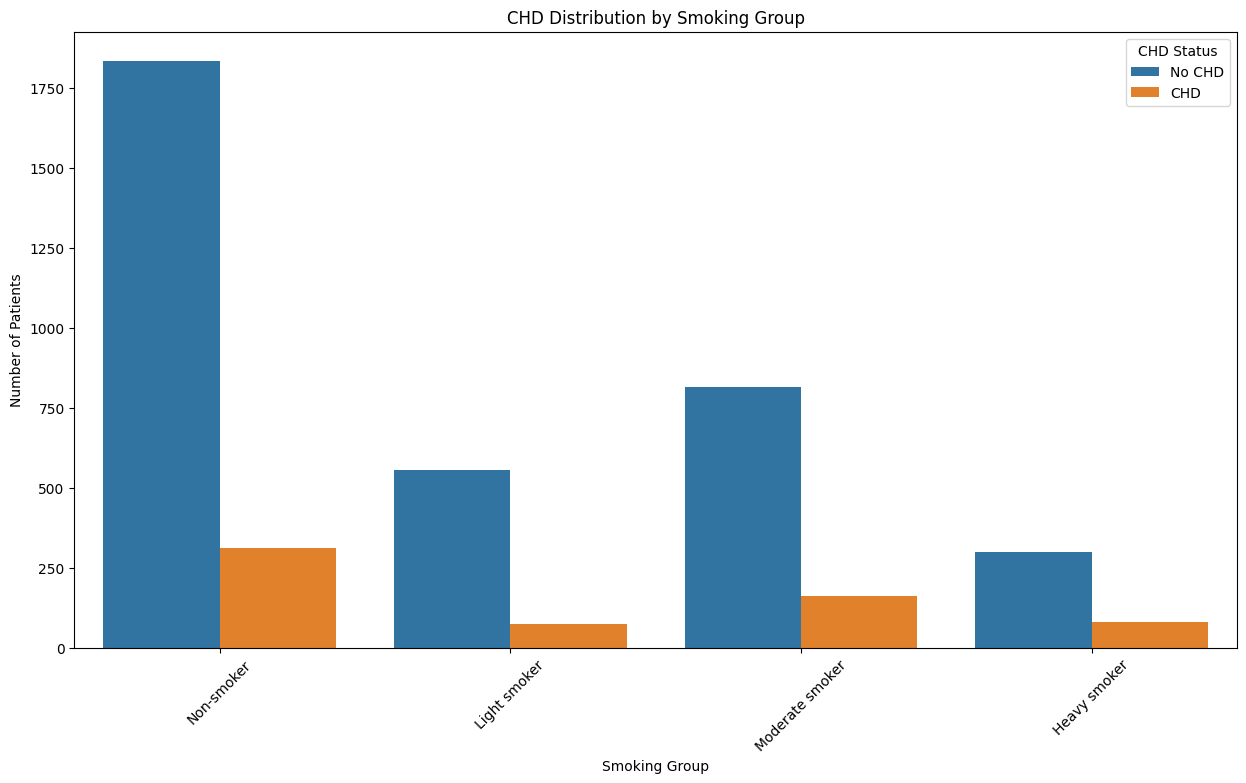

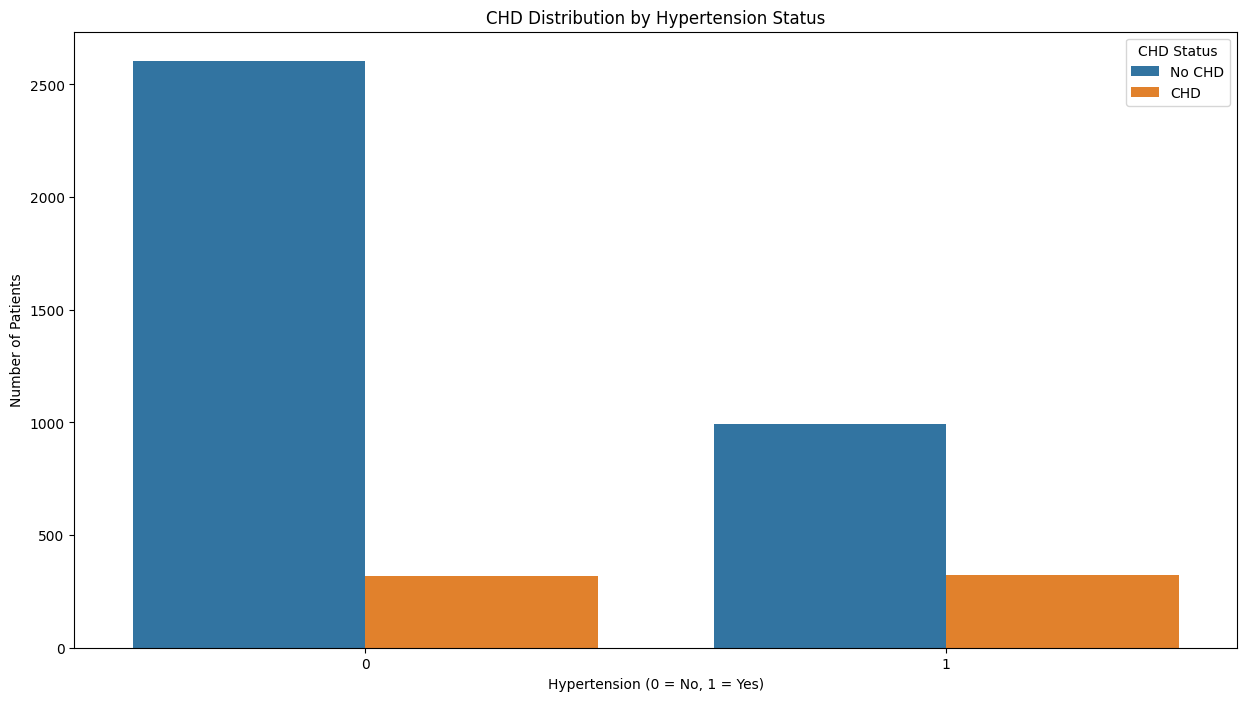

In [38]:
# Create smoking groups based on cigarettes per day
df['smoking_group'] = pd.cut(
    df['cigsPerDay'],
    bins=[-1, 0, 10, 20, 40],
    labels=['Non-smoker', 'Light smoker', 'Moderate smoker', 'Heavy smoker']
)

plt.figure(figsize=(15, 8))

sns.countplot(
    data=df,
    x='smoking_group',
    hue='TenYearCHD'
)

plt.title('CHD Distribution by Smoking Group')
plt.xlabel('Smoking Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.legend(title='CHD Status', labels=['No CHD', 'CHD'])

plt.show()


# Does hypertension increase CHD risk?

plt.figure(figsize=(15, 8))

sns.countplot(
    data=df,
    x='prevalentHyp',
    hue='TenYearCHD'
)

plt.title('CHD Distribution by Hypertension Status')
plt.xlabel('Hypertension (0 = No, 1 = Yes)')
plt.ylabel('Number of Patients')
plt.legend(title='CHD Status', labels=['No CHD', 'CHD'])

plt.show()

Missing Values and Outliers

In [43]:
df_clean = df.copy()

# Imputation of missing values for numerical variables
df_clean['glucose'] = df_clean['glucose'].fillna(df_clean['glucose'].median())
df_clean['totChol'] = df_clean['totChol'].fillna(df_clean['totChol'].median())
df_clean['BMI'] = df_clean['BMI'].fillna(df_clean['BMI'].median())
df_clean['heartRate'] = df_clean['heartRate'].fillna(df_clean['heartRate'].median())
df_clean['cigsPerDay'] = df_clean['cigsPerDay'].fillna(df_clean['cigsPerDay'].median())

# Imputation of missing values for categorical variables
df_clean['education'] = df_clean['education'].fillna(df_clean['education'].mode()[0])
df_clean['BPMeds'] = df_clean['BPMeds'].fillna(df_clean['BPMeds'].mode()[0])

# List columns with remaining missing values
df_missing = df_clean.isnull().sum()
df_missing = df_missing[df_missing > 0].reset_index()

# Calculate percentage of missing values
df_missing['percentage'] = (df_missing[0] / len(df_clean)) * 100

df_missing
#help with AI to replace my previous code

/var/folders/1l/dzqt98xj2z109y7jzxytr_kh0000gn/T/ipykernel_3904/2665716417.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['education'] = df_clean['education'].fillna(df_clean['education'].mode()[0])
/var/folders/1l/dzqt98xj2z109y7jzxytr_kh0000gn/T/ipykernel_3904/2665716417.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['BPMeds'] = df_clean['BPMeds'].fillna(df_clean['BPMeds'].mode()[0])


,index,0,percentage
0,smoking_group,29,0.683962


Modify smoking group to get less NaN

In [42]:
df['smoking_group'] = pd.cut(
    df['cigsPerDay'],
    bins=[-1, 0, 10, 20, 40, float('inf')],
    labels=['Non-smoker', 'Light smoker', 'Moderate smoker', 'Heavy smoker', 'Very heavy smoker']
)

Display after cleaning

In [44]:
df_clean[numeric_cols].head()

,age,cigsPerDay,totChol,sysBP,diaBP,BMI,heartRate,glucose
0,39,0.0,195.0,106.0,70.0,26.97,80.0,77.0
1,46,0.0,250.0,121.0,81.0,28.73,95.0,76.0
2,48,20.0,245.0,127.5,80.0,25.34,75.0,70.0
3,61,30.0,225.0,150.0,95.0,28.58,65.0,103.0
4,46,23.0,285.0,130.0,84.0,23.10,85.0,85.0


High Cardinality Analysis

In [45]:
# Check cardinality of numerical variables
df_clean[numeric_cols].nunique().sort_values(ascending=False)

# Select variables with more than 50 unique values
high_cardinality = [
    col for col in df_clean[numeric_cols].columns
    if df_clean[col].nunique() > 50
]

# Create dataframe with high-cardinality numerical variables
df_clean_num_high_cardinality = df_clean[high_cardinality]

high_cardinality

['totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

Density histograms for high-cardinality numerical variables

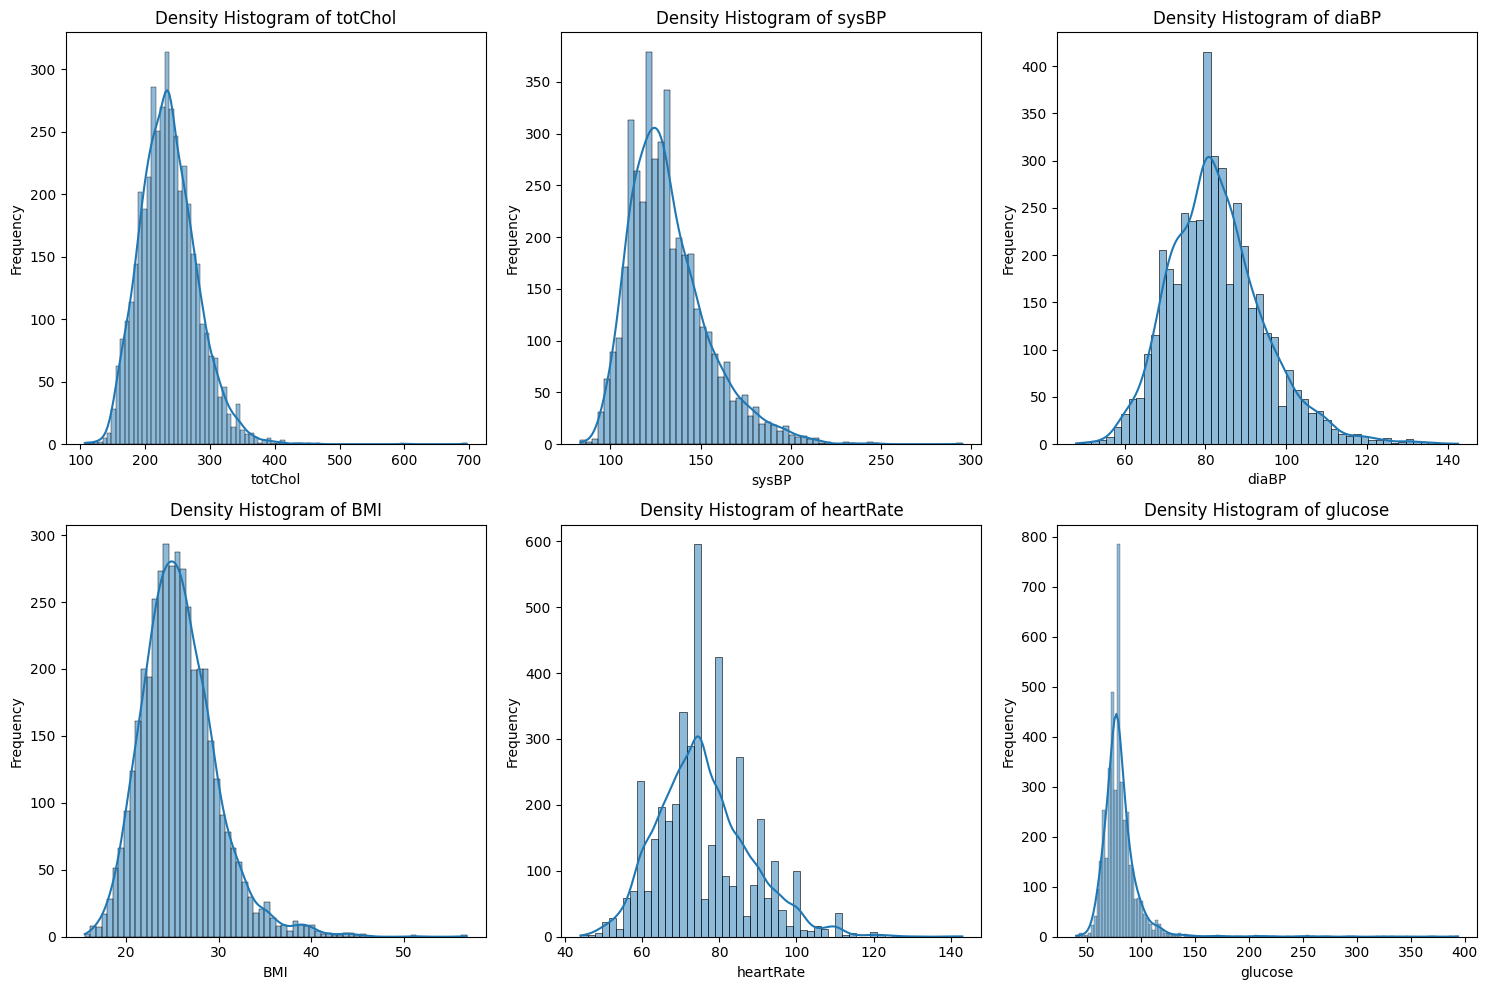

In [46]:
# Define number of columns
ncols = 3
nrows = (len(df_clean_num_high_cardinality.columns) + ncols - 1) // ncols

fig, axs = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(15, 5 * nrows)
)

for i, column in enumerate(df_clean_num_high_cardinality.columns):
    row = i // ncols
    col = i % ncols

    sns.histplot(
        df_clean_num_high_cardinality[column],
        kde=True,
        ax=axs[row, col]
    )

    axs[row, col].set_title(f'Density Histogram of {column}')
    axs[row, col].set_xlabel(column)
    axs[row, col].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Interquartile Range (IQR) for high-cardinality numerical variables

In [47]:
df_clean_num_high_cardinality.quantile(0.75) - df_clean_num_high_cardinality.quantile(0.25)

totChol      56.000
sysBP        27.000
diaBP        15.000
BMI           4.955
heartRate    15.000
glucose      13.000
dtype: float64

IQR-based outlier treatment for high-cardinality numerical variables

In [48]:
iqr = (
    df_clean_num_high_cardinality.quantile(0.75)
    - df_clean_num_high_cardinality.quantile(0.25)
)

def iqr_winsorize(df, columns, iqr_threshold=1.5, winsorize_threshold=0.95):
    """
    Outlier treatment using IQR when possible.
    If IQR = 0, upper-tail winsorization is applied at the 95th percentile.
    """
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)

        if q1 != q3:
            iqr_value = q3 - q1
            lower_bound = q1 - iqr_threshold * iqr_value
            upper_bound = q3 + iqr_threshold * iqr_value

            df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
            df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

        else:
            upper_bound = df[col].quantile(winsorize_threshold)
            df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

    return df


df_clean_num_high_cardinality = iqr_winsorize(
    df_clean_num_high_cardinality,
    high_cardinality
)

/var/folders/1l/dzqt98xj2z109y7jzxytr_kh0000gn/T/ipykernel_3904/2448768669.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
/var/folders/1l/dzqt98xj2z109y7jzxytr_kh0000gn/T/ipykernel_3904/2448768669.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
/var/folders/1l/dzqt98xj2z109y7jzxytr_kh0000gn/T/ipykernel_3904/2448768669.py:20: SettingWithCopyWarning: 
A value is trying to 

In [51]:
print('High-cardinality variables before outlier treatment')
df_clean[high_cardinality].describe(percentiles=[.25, .5, .75, .9, .95, .99]).T.sort_values(by='50%', ascending=False).style.background_gradient(cmap='CMRmap')

High-cardinality variables before outlier treatment


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
totChol,4240.000000,236.667689,44.328480,107.000000,206.000000,234.000000,262.000000,292.000000,312.000000,353.610000,696.000000
sysBP,4240.000000,132.354599,22.033300,83.500000,117.000000,128.000000,144.000000,162.000000,175.000000,200.000000,295.000000
diaBP,4240.000000,82.897759,11.910394,48.000000,75.000000,82.000000,90.000000,98.000000,104.525000,118.000000,142.500000
glucose,4240.000000,81.600943,22.860340,40.000000,72.000000,78.000000,85.000000,97.000000,107.000000,170.000000,394.000000
heartRate,4240.000000,75.878774,12.023937,44.000000,68.000000,75.000000,83.000000,92.000000,98.000000,110.000000,143.000000
BMI,4240.000000,25.799005,4.070775,15.540000,23.077500,25.400000,28.032500,30.761000,32.770500,38.952200,56.800000


In [50]:
print("High-cardinality variables after outlier treatment")

df_clean_num_high_cardinality.describe(
    percentiles=[.25, .5, .75, .90, .95, .99]
).T.sort_values(
    by='50%',
    ascending=False
).style.background_gradient(cmap='coolwarm')

High-cardinality variables after outlier treatment


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
totChol,4240.000000,236.170047,42.299175,122.000000,206.000000,234.000000,262.000000,292.000000,312.000000,346.000000,346.000000
sysBP,4240.000000,131.915684,20.642860,83.500000,117.000000,128.000000,144.000000,162.000000,175.000000,184.500000,184.500000
diaBP,4240.000000,82.743042,11.404757,52.500000,75.000000,82.000000,90.000000,98.000000,104.525000,112.500000,112.500000
glucose,4240.000000,79.450472,11.453158,52.500000,72.000000,78.000000,85.000000,97.000000,104.500000,104.500000,104.500000
heartRate,4240.000000,75.750708,11.622274,45.500000,68.000000,75.000000,83.000000,92.000000,98.000000,105.500000,105.500000
BMI,4240.000000,25.714098,3.787978,15.645000,23.077500,25.400000,28.032500,30.761000,32.770500,35.465000,35.465000


Multivariate Analysis

In [52]:
print(numeric_cols)

['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']


Pairplot for numeric cols

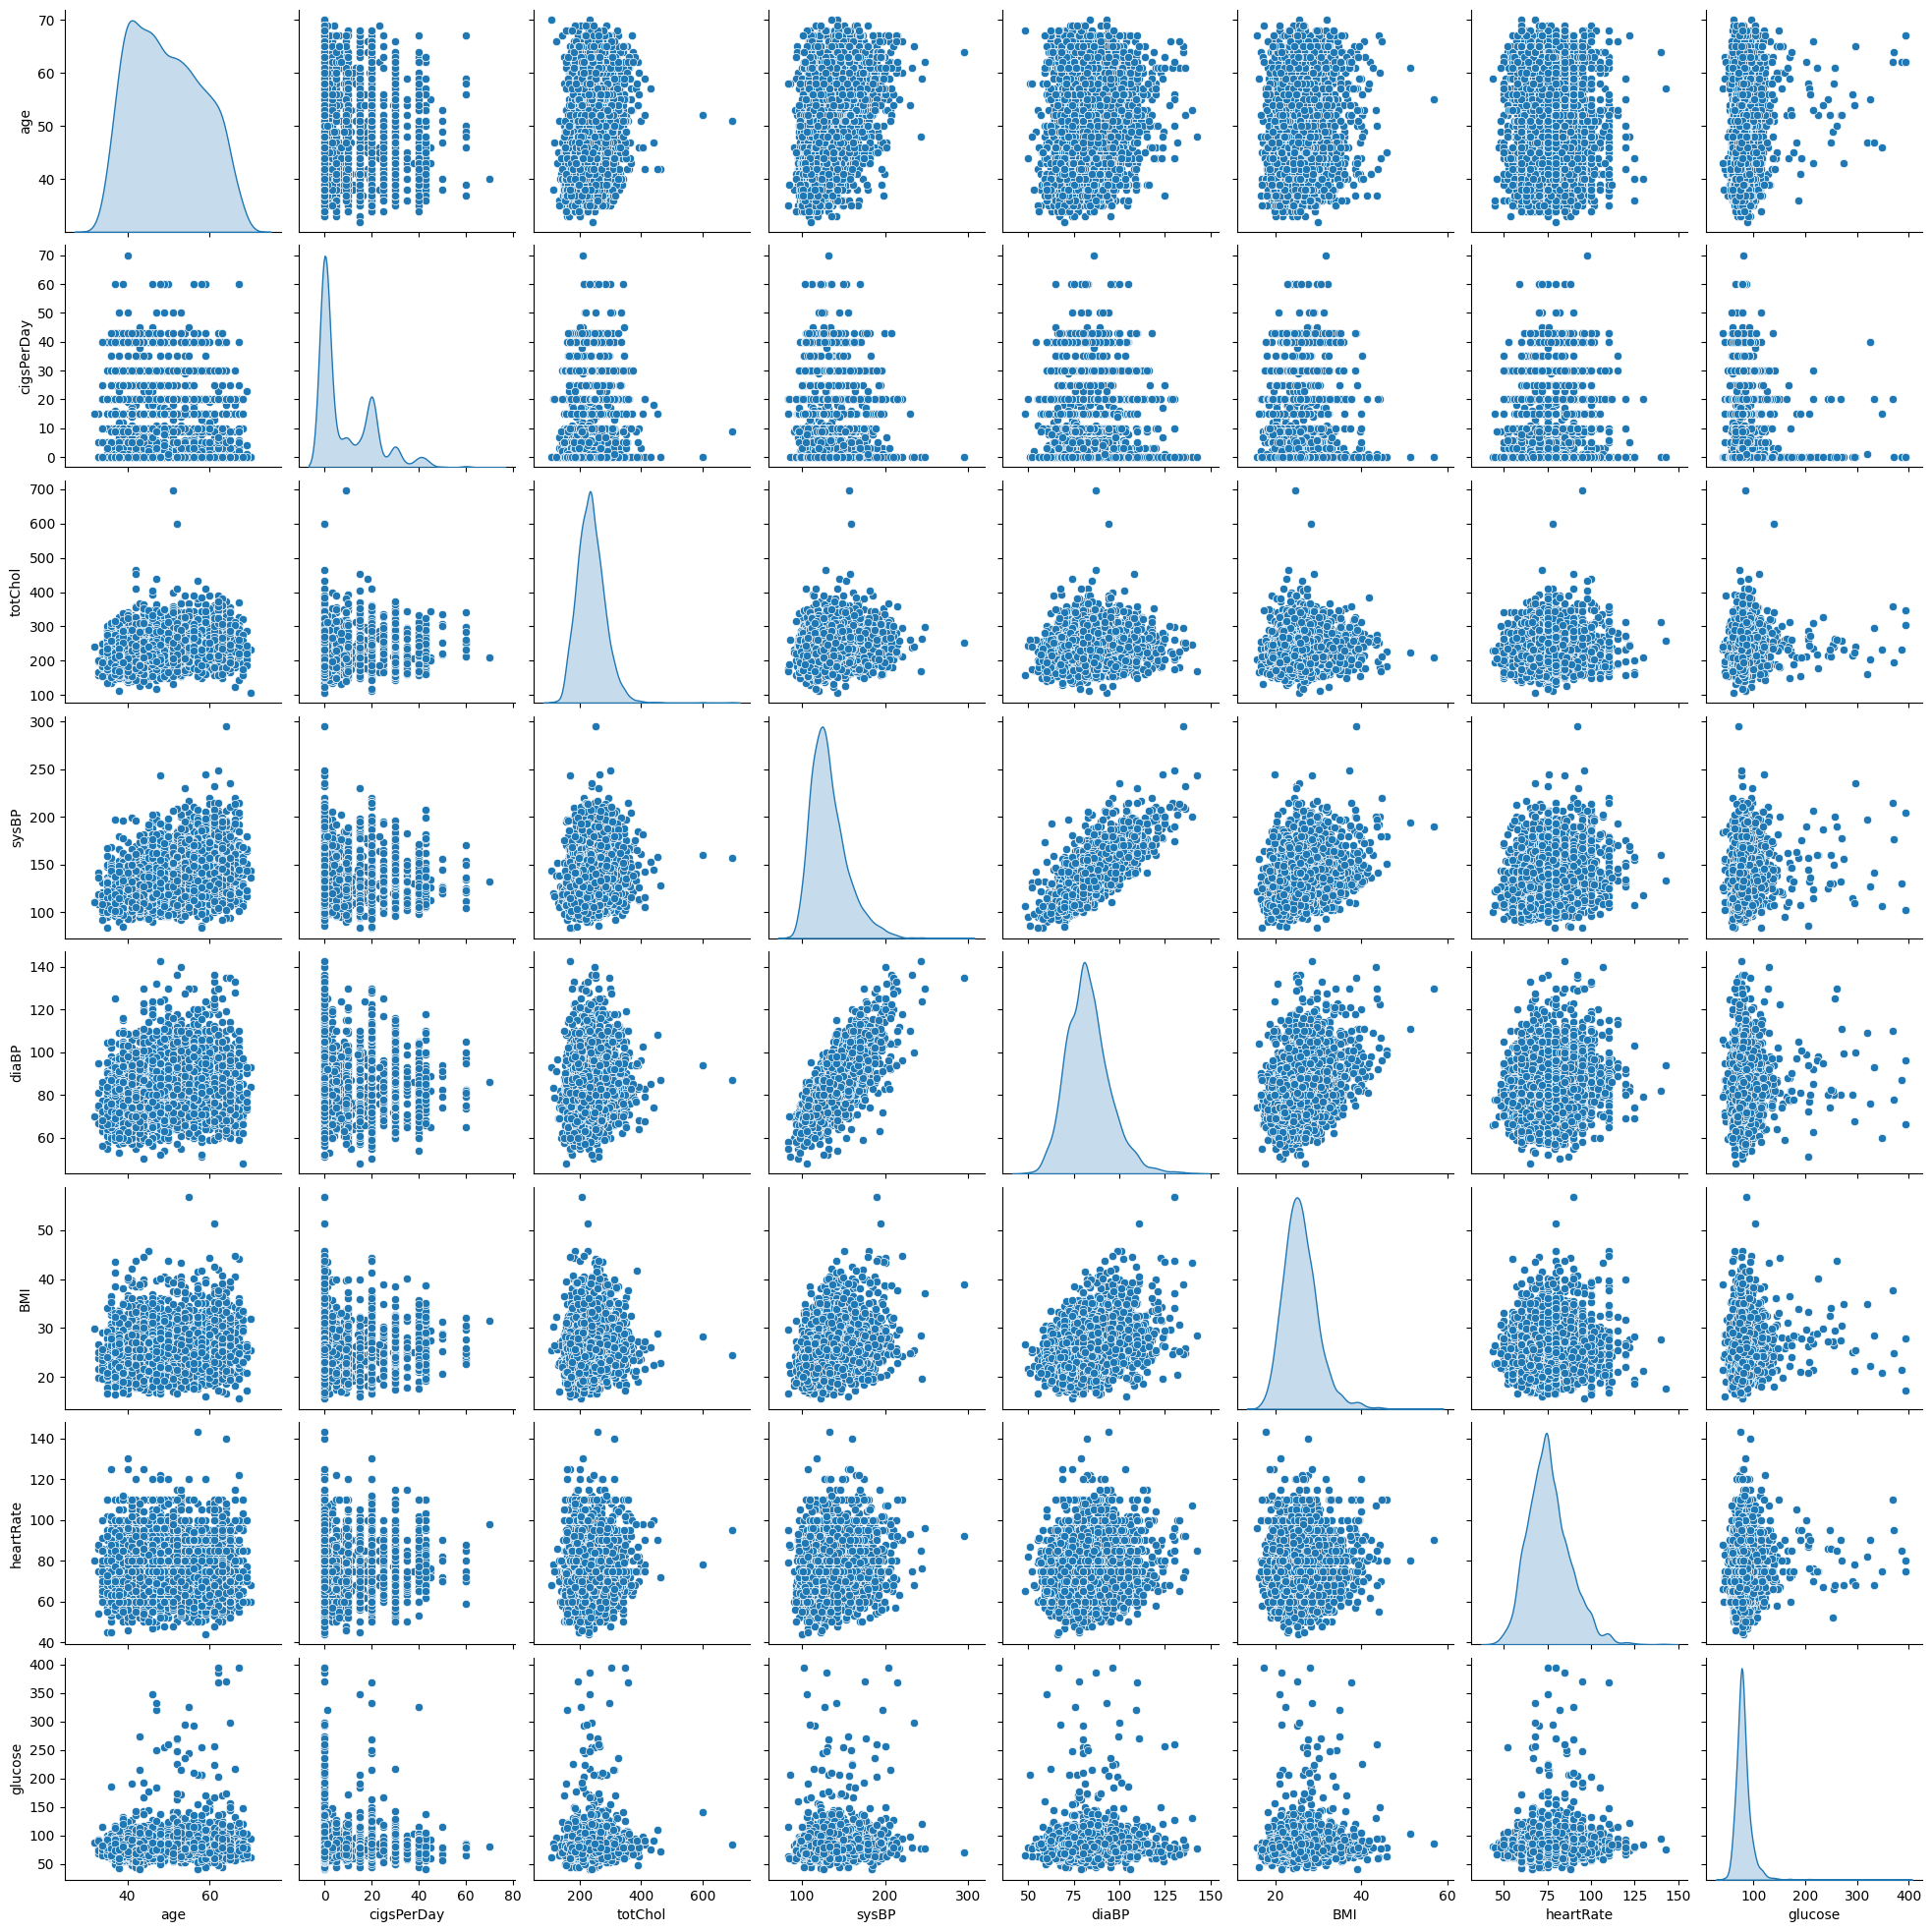

In [53]:
sns.pairplot(
    df_clean[numeric_cols],
    diag_kind='kde'
)

plt.show()

Correlation Target

In [54]:
numeric_cols_with_target = numeric_cols.copy()
numeric_cols_with_target.append('TenYearCHD')

corr = df_clean[numeric_cols_with_target].corr()

corr_target = corr['TenYearCHD'].sort_values(ascending=False)

corr_target

TenYearCHD    1.000000
age           0.225408
sysBP         0.216374
diaBP         0.145112
glucose       0.121319
totChol       0.081749
BMI           0.074326
cigsPerDay    0.058729
heartRate     0.022851
Name: TenYearCHD, dtype: float64

Analyze relationships between categorical variables using Chi-square test

In [56]:
from scipy.stats import chi2_contingency

def chi_square_test(df, col1, col2):
    contingency_table = pd.crosstab(df[col1], df[col2])
    chi2, p, _, _ = chi2_contingency(contingency_table)
    return chi2, p


def analyze_categorical_relationships(df, categorical_cols):
    results = []

    for i in range(len(categorical_cols)):
        for j in range(i + 1, len(categorical_cols)):
            col1 = categorical_cols[i]
            col2 = categorical_cols[j]

            chi2, p = chi_square_test(df, col1, col2)
            results.append((col1, col2, chi2, p))

    return results


categorical_relationships = analyze_categorical_relationships(
    df_clean,
    categorical_cols
)

results_df = pd.DataFrame(
    categorical_relationships,
    columns=['col1', 'col2', 'chi2', 'p-value']
)

results_df['significant'] = results_df['p-value'] < 0.05

results_df['p-value'] = results_df['p-value'].apply(
    lambda x: '{:.2e}'.format(x)
)

results_df['chi2'] = results_df['chi2'].apply(
    lambda x: '{:.2f}'.format(x)
)

results_df.sort_values(
    by='chi2',
    ascending=False,
    inplace=True
)

results_df
#Ayuda IA

,col1,col2,chi2,p-value,significant
20,BPMeds,diabetes,9.36,2.22e-03,True
13,currentSmoker,BPMeds,9.35,2.24e-03,True
0,male,education,88.23,5.25e-19,True
16,currentSmoker,diabetes,7.77,5.33e-03,True
18,BPMeds,prevalentStroke,47.17,6.52e-12,True
15,currentSmoker,prevalentHyp,45.16,1.82e-11,True
9,education,prevalentStroke,4.79,1.88e-01,False
27,diabetes,TenYearCHD,38.48,5.53e-10,True
10,education,prevalentHyp,33.35,2.71e-07,True
6,male,TenYearCHD,32.62,1.12e-08,True


Correlation Heatmap

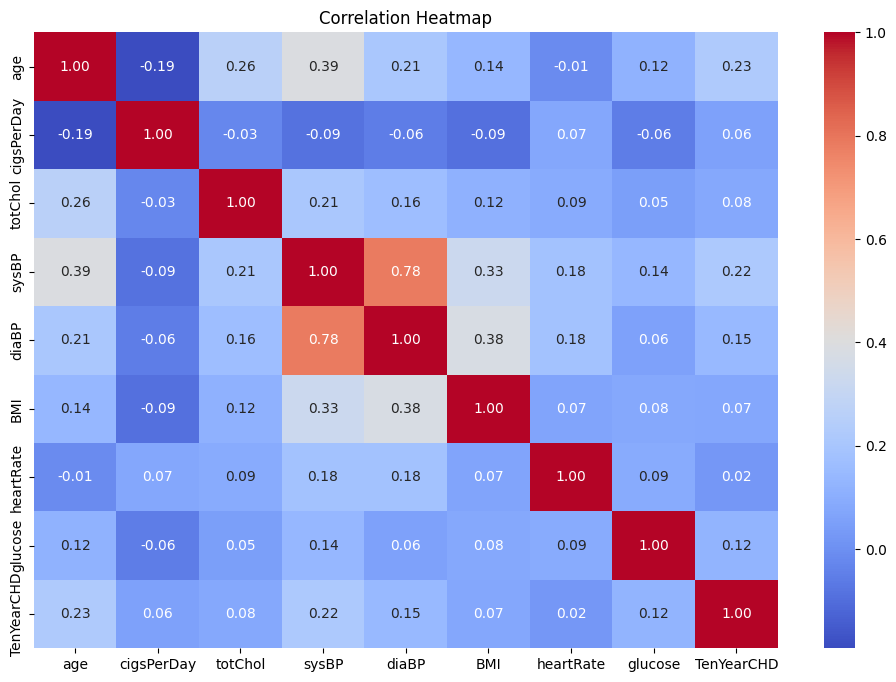

In [58]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df_clean[numeric_cols_with_target].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

High Risk Profile for CHD

In [59]:
high_risk_profile = df_clean.groupby('TenYearCHD')[[
    'age',
    'sysBP',
    'glucose',
    'totChol',
    'cigsPerDay',
    'BMI'
]].mean()

high_risk_profile

,age,sysBP,glucose,totChol,cigsPerDay,BMI
TenYearCHD,,,,,,
0,48.762514,130.337319,80.427419,235.134316,8.648498,25.670979
1,54.145963,143.618789,88.153727,245.229814,10.596273,26.513882


No tengo el tiempo para terminar pero se que hay que hacer mas en la multivariante.